# ATN DAC Quality Control Example - Trajectory Data

This notebook demonstrates how to apply QARTOD quality control tests to Animal Telemetry Network (ATN) satellite telemetry trajectory data using the [`ioos_qc`](https://github.com/ioos/ioos_qc) Python package (see [docs](https://ioos.github.io/ioos_qc/)).

The ATN DAC applies automated quality control to all auto-ingested trajectory and profile data from Wildlife Computers and SMRU instruments. This notebook shows the exact tests and thresholds used in our operational pipeline, allowing users to:

1. Understand what QC is being applied to ATN data
2. Replicate the QC process on their own data
3. Interpret the QARTOD flags embedded in ATN data products

Please see the [ATN Satellite Telemetry Specifications, Quality Control Protocols section](https://ioos.github.io/ioos-atn-data/atn-sat-telem-specification-v1-0.html#quality-control-protocols) for more details on QC flag values, tests applied, and configured thresholds.

## Import Required Libraries

In [1]:
# Core data handling
import pandas as pd
import numpy as np
import io
import zipfile
import requests

# QC libraries
from ioos_qc.config import Config
from ioos_qc.streams import PandasStream
from ioos_qc.stores import PandasStore
from ioos_qc.utils import great_circle_distance

# Visualization
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Fetch ATN Data

We'll use **real deployment data** from the ATN Data Assembly Center. This example uses deployment **254060O2024** which contains Wildlife Computers satellite tag data.

The data is accessed directly from the ATN data portal at [portal.atn.ioos.us](https://portal.atn.ioos.us).

### Wildlife Computers Data Format

Wildlife Computers tags produce several data types:
- **Argos** - Satellite-derived positions with location class quality indicators
- **FastGPS** - Higher-accuracy GPS positions (when available)
- **Series** - Time-series data (temperature, depth)
- **Histos** - Histogram summaries of behavior

For trajectory QC, we primarily use the **Argos** position data which includes:
- Date/time of each position fix
- Latitude and Longitude
- Location Class (quality indicator: 3, 2, 1, 0, A, B, Z)
- Error ellipse parameters

In [2]:
# Download real ATN deployment data from Wildlife Computers
# This is deployment 254060O2024 - a real tagged animal track

deployment_url = "https://workspace.aoos.org/published/file/1989e709-af65-4250-9413-637d5cea36f4/254053O2024.zip?source=catalog&portalId=99"
# deployment_url = "https://workspace.aoos.org/published/file/9d318aa0-e818-4473-90d5-157c0f3dd186/254060O2024.zip?source=catalog&portalId=99"


print(f"Downloading deployment data from ATN...")
response = requests.get(deployment_url)
response.raise_for_status()

# Extract the ZIP file contents
zip_buffer = io.BytesIO(response.content)
zf = zipfile.ZipFile(zip_buffer)

# List files in the ZIP
print(f"\nFiles in deployment ZIP:")
for filename in sorted(zf.namelist()):
    print(f"  - {filename}")


Files in deployment ZIP:
  - 254053O2024/
  - 254053O2024/254053-10-GPE3.csv
  - 254053O2024/254053-10-GPE3.kmz
  - 254053O2024/254053-10-GPE3.nc
  - 254053O2024/254053-All.csv
  - 254053O2024/254053-Argos.csv
  - 254053O2024/254053-Corrupt.csv
  - 254053O2024/254053-Histos.csv
  - 254053O2024/254053-Labels.csv
  - 254053O2024/254053-LightLoc.csv
  - 254053O2024/254053-Locations.csv
  - 254053O2024/254053-MinMaxDepth.csv
  - 254053O2024/254053-MixLayer.csv
  - 254053O2024/254053-PDTs.csv
  - 254053O2024/254053-RTC.csv
  - 254053O2024/254053-RawArgos.csv
  - 254053O2024/254053-SST.csv
  - 254053O2024/254053-Series.csv
  - 254053O2024/254053-SeriesRange.csv
  - 254053O2024/254053-Status.csv
  - 254053O2024/254053-Summary.csv
  - 254053O2024/254053.kmz
  - 254053O2024/254053.prv
  - 254053O2024/254053.pxp
  - 254053O2024/setup.rtf
  - 254053O2024/sources.txt


## QC Trajectory Data

### Prepare Data

In [9]:
# Load the Argos position data in the Locations file for trajectory QC

# argos_file = None
for filename in zf.namelist():
    if '-Locations.csv' in filename or filename.endswith('Locations.csv'):
        argos_file = filename
        break

# if argos_file:
print(f"Loading Argos data from: {argos_file}")
with zf.open(argos_file) as f:
    trajectory_df = pd.read_csv(f)

print(f"\nLoaded {len(trajectory_df)} trajectory points")
print(f"\nColumns in Argos file:")
for col in trajectory_df.columns:
    print(f"  - {col}")
# else:
#     # If no Argos file, look for any position data
#     print("No Argos file found, searching for position data...")
#     for filename in zf.namelist():
#         if filename.endswith('.csv'):
#             print(f"  Checking: {filename}")
#             with zf.open(filename) as f:
#                 df_check = pd.read_csv(f, nrows=5)
#                 if 'Latitude' in df_check.columns or 'latitude' in df_check.columns.str.lower():
#                     print(f"  -> Found position data!")
#                     with zf.open(filename) as f2:
#                         trajectory_df = pd.read_csv(f2)
#                     break

Loading Argos data from: 254053O2024/254053-Locations.csv

Loaded 629 trajectory points

Columns in Argos file:
  - DeployID
  - Ptt
  - Instr
  - Date
  - Type
  - Quality
  - Latitude
  - Longitude
  - Error radius
  - Error Semi-major axis
  - Error Semi-minor axis
  - Error Ellipse orientation
  - Offset
  - Offset orientation
  - GPE MSD
  - GPE U
  - Count
  - Comment


In [10]:
# Examine the trajectory data structure
print("Data shape:", trajectory_df.shape)
print(f"\nDate range: {trajectory_df['Date'].min()} to {trajectory_df['Date'].max()}")

# Show first few records
print("\nFirst 5 records:")
trajectory_df.head()

Data shape: (629, 18)

Date range: 00:02:32 06-Apr-2024 to 23:59:54 03-Apr-2024

First 5 records:


,DeployID,Ptt,Instr,Date,Type,Quality,Latitude,Longitude,Error radius,Error Semi-major axis,Error Semi-minor axis,Error Ellipse orientation,Offset,Offset orientation,GPE MSD,GPE U,Count,Comment
0,254053,254053,MiniPAT,02:03:56 31-Mar-2024,Argos,0,11.8863,-100.2372,4738,13416.0,1673.0,28.0,NaN,NaN,NaN,NaN,NaN,NaN
1,254053,254053,MiniPAT,02:30:43 31-Mar-2024,Argos,2,11.9007,-100.2494,347,454.0,264.0,60.0,NaN,NaN,NaN,NaN,NaN,NaN
2,254053,254053,MiniPAT,03:03:54 31-Mar-2024,Argos,1,11.9024,-100.2447,901,2404.0,337.0,49.0,NaN,NaN,NaN,NaN,NaN,NaN
3,254053,254053,MiniPAT,03:40:08 31-Mar-2024,Argos,1,11.8957,-100.2561,704,1801.0,275.0,81.0,NaN,NaN,NaN,NaN,NaN,NaN
4,254053,254053,MiniPAT,04:27:03 31-Mar-2024,Argos,2,11.8882,-100.2766,425,767.0,235.0,84.0,NaN,NaN,NaN,NaN,NaN,NaN


### 1. Explore the Trajectory Data

Let's examine the data to understand what we're working with before applying QC.

/Users/iwen/miniforge3/envs/atn/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/iwen/miniforge3/envs/atn/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/iwen/miniforge3/envs/atn/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/iwen/miniforge3/envs/atn/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


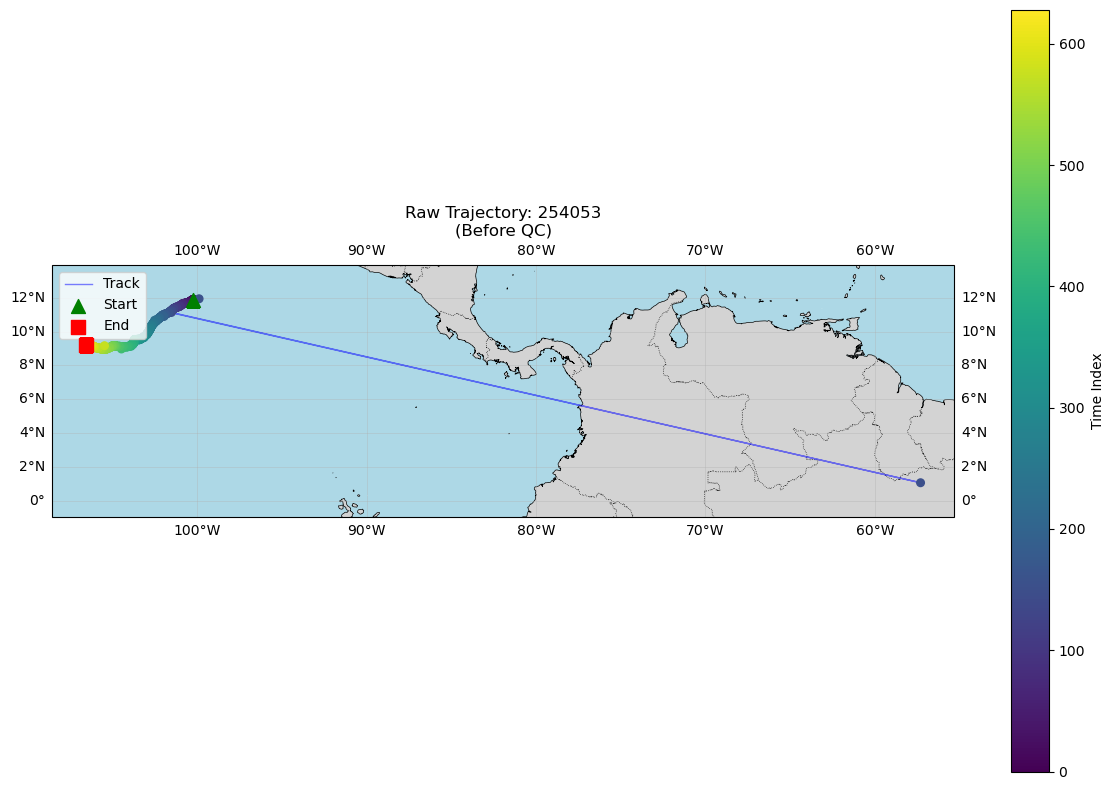


Total points: 629, Valid coordinates: 629


In [11]:
# Visualize the raw track before QC
fig, ax = plt.subplots(1, 1, figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Find lat/lon columns
lat_col = [c for c in trajectory_df.columns if 'lat' in c.lower()][0]
lon_col = [c for c in trajectory_df.columns if 'lon' in c.lower()][0]

# Filter valid coordinates for extent calculation
valid_mask = (trajectory_df[lat_col].between(-90, 90)) & (trajectory_df[lon_col].between(-180, 180))
valid_data = trajectory_df[valid_mask]

# Set map extent with some padding
lon_min, lon_max = valid_data[lon_col].min() - 2, valid_data[lon_col].max() + 2
lat_min, lat_max = valid_data[lat_col].min() - 2, valid_data[lat_col].max() + 2

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

# Plot trajectory
ax.plot(valid_data[lon_col], valid_data[lat_col],
        'b-', linewidth=1, alpha=0.5, transform=ccrs.PlateCarree(), label='Track')
map = ax.scatter(valid_data[lon_col], valid_data[lat_col], 
           c=range(len(valid_data)), cmap='viridis', s=30, 
           transform=ccrs.PlateCarree(), zorder=5)
plt.colorbar(map, ax=ax, orientation='vertical', label='Time Index')

# Mark start and end
ax.scatter(valid_data[lon_col].iloc[0], valid_data[lat_col].iloc[0],
           c='green', s=100, marker='^', transform=ccrs.PlateCarree(), 
           zorder=10, label='Start')
ax.scatter(valid_data[lon_col].iloc[-1], valid_data[lat_col].iloc[-1],
           c='red', s=100, marker='s', transform=ccrs.PlateCarree(), 
           zorder=10, label='End')

# Get deployment ID if available
deploy_id = trajectory_df['DeployID'].iloc[0] if 'DeployID' in trajectory_df.columns else 'Unknown'

ax.legend(loc='upper left')
ax.set_title(f"Raw Trajectory: {deploy_id}\n(Before QC)")
plt.tight_layout()
plt.show()

print(f"\nTotal points: {len(trajectory_df)}, Valid coordinates: {len(valid_data)}")

### 2. Configure QC Tests

Now we'll configure the QC tests using `ioos_qc`. The ATN DAC applies the   Location Test and Speed Test to trajectory data to ensure positions fall within valid geographic bounds and checks for biologically implausable movement speeds.

In [14]:
# Prepare data for QC
# Standardize column names and convert datetime

# Find the relevant columns
lat_col = [c for c in trajectory_df.columns if 'lat' in c.lower()][0]
lon_col = [c for c in trajectory_df.columns if 'lon' in c.lower()][0]
date_col = [c for c in trajectory_df.columns if 'date' in c.lower()][0]

# Create QC dataframe with standardized names
qc_df = trajectory_df.copy()
qc_df['lat'] = qc_df[lat_col]
qc_df['lon'] = qc_df[lon_col]

# Parse datetime
qc_df['time'] = pd.to_datetime(qc_df[date_col])
qc_df = qc_df.sort_values('time').reset_index(drop=True)

# Convert to Unix timestamp for speed calculations
qc_df['timestamp'] = qc_df['time'].astype('int64') / 1e9

print("Data prepared for QC:")
print(f"  Records: {len(qc_df)}")
print(f"  Date range: {qc_df['time'].min()} to {qc_df['time'].max()}")
print(f"  Lat range: {qc_df['lat'].min():.3f} to {qc_df['lat'].max():.3f}")
print(f"  Lon range: {qc_df['lon'].min():.3f} to {qc_df['lon'].max():.3f}")

# qc_df[['time', 'lat', 'lon', 'timestamp']].head()

Data prepared for QC:
  Records: 629
  Date range: 2024-03-31 02:03:56 to 2024-04-19 04:35:53
  Lat range: 1.075 to 11.940
  Lon range: -106.586 to -57.298


In [15]:
# QC Test Thresholds used by ATN DAC
# These are defined based on biological plausibility for marine animals

QC_THRESHOLDS = {
    'location_test': {
        'bbox': [-180, -90, 180, 90],  # Global ocean bounds [lon_min, lat_min, lon_max, lat_max]
        'description': 'Flags positions outside valid geographic range'
    },
    'speed_test': {
        'suspect_threshold': 8.0,  # m/s - high speed, possibly valid for fast swimmers
        'fail_threshold': 10.0,    # m/s - biologically impossible for most marine animals
        'description': 'Flags unrealistic movement speeds between consecutive positions'
    }
}

# # Display thresholds
# print("ATN DAC QC Thresholds for Trajectory Data")
# print("="*50)
# for test_name, params in QC_THRESHOLDS.items():
#     print(f"\n{test_name}:")
#     print(f"  Description: {params['description']}")
#     for k, v in params.items():
#         if k != 'description':
#             print(f"  {k}: {v}")

### 3. Execute QC Tests

Now we'll run the QARTOD QC tests using `ioos_qc`. We'll apply:

1. **Location Test** - Validates that coordinates fall within valid geographic bounds
2. **Speed Test** - Calculates velocity between consecutive points and flags unrealistic speeds

The tests are run directly using the `ioos_qc.qartod` and `ioos_qc.argo` modules.

In [16]:
# Run Location Test
from ioos_qc.qartod import location_test

location_flags = location_test(
    lon=qc_df['lon'].values,
    lat=qc_df['lat'].values,
    bbox=QC_THRESHOLDS['location_test']['bbox']
)

qc_df['location_test'] = location_flags

print("Location test completed!")
print(f"\nLocation test flag distribution:")
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in pd.Series(location_flags).value_counts().sort_index().items():
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count}")

# Show any failed locations
failed_locs = qc_df[qc_df['location_test'] == 4]
if len(failed_locs) > 0:
    print(f"\nPoints that failed location test: {len(failed_locs)}")
    print(failed_locs[['time', 'lat', 'lon', 'location_test']].head())
else:
    print("\n✓ All positions passed the location test")

Location test completed!

Location test flag distribution:
  PASS (1): 629

✓ All positions passed the location test


In [17]:
# Run speed test - calculates velocity between consecutive points
from ioos_qc.argo import speed_test

dist = great_circle_distance(qc_df['lat'].values, qc_df['lon'].values)
time_diff = np.diff(qc_df['timestamp'].values)
calculated_speed = np.zeros(len(qc_df))
calculated_speed[1:] = np.abs(dist[1:] / time_diff)

# Calculate speeds for plotting (this is done internally in ioos_qc)
qc_df['calculated_speed'] = calculated_speed

# Run ioos_qc speed test
speed_flags = speed_test(
    lon=qc_df['lon'].values,
    lat=qc_df['lat'].values,
    tinp=qc_df['timestamp'].values,
    suspect_threshold=8.0,
    fail_threshold=10.0
)

qc_df['speed_test'] = speed_flags

print("Speed test completed!")
print(f"\nSpeed statistics (m/s):")
print(f"  Min: {qc_df['calculated_speed'].min():.4f}")
print(f"  Max: {qc_df['calculated_speed'].max():.4f}")
print(f"  Mean: {qc_df['calculated_speed'].mean():.4f}")
print(f"  Median: {qc_df['calculated_speed'].median():.4f}")

# Show flag distribution
print(f"\nSpeed test flag distribution:")
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in pd.Series(speed_flags).value_counts().sort_index().items():
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count}")

Speed test completed!

Speed statistics (m/s):
  Min: 0.0000
  Max: 56499.0716
  Mean: 99.9178
  Median: 0.7894

Speed test flag distribution:
  PASS (1): 577
  NOT_EVAL (2): 1
  SUSPECT (3): 6
  FAIL (4): 45


### 4. Interpret QC Flags

The QC tests produce standardized QARTOD flag values. Let's create a summary of results and understand what each flag means for our data quality.

In [18]:
# Create an aggregate QC flag
# The aggregate takes the worst (highest) flag from all tests

qc_df['qc_aggregate'] = np.maximum(qc_df['location_test'], qc_df['speed_test'])

# Summary statistics
print("="*60)
print("QARTOD QC SUMMARY")
print("="*60)
print(f"\nTotal trajectory points: {len(qc_df)}")
print(f"\n{'Test':<20} {'Pass':<10} {'Suspect':<10} {'Fail':<10}")
print("-"*50)

for test_name in ['location_test', 'speed_test', 'qc_aggregate']:
    flags = qc_df[test_name]
    n_pass = (flags == 1).sum()
    n_suspect = (flags == 3).sum()
    n_fail = (flags == 4).sum()
    print(f"{test_name:<20} {n_pass:<10} {n_suspect:<10} {n_fail:<10}")

print("\n" + "="*60)

# Calculate pass rate
good_data = (qc_df['qc_aggregate'] == 1).sum()
suspect_data = (qc_df['qc_aggregate'] == 3).sum()
fail_data = (qc_df['qc_aggregate'] == 4).sum()

print(f"\nData Quality Summary:")
print(f"  Good data (flag=1):     {good_data:4d} ({100*good_data/len(qc_df):.1f}%)")
print(f"  Suspect data (flag=3):  {suspect_data:4d} ({100*suspect_data/len(qc_df):.1f}%)")
print(f"  Failed data (flag=4):   {fail_data:4d} ({100*fail_data/len(qc_df):.1f}%)")

QARTOD QC SUMMARY

Total trajectory points: 629

Test                 Pass       Suspect    Fail      
--------------------------------------------------
location_test        629        0          0         
speed_test           577        6          45        
qc_aggregate         577        6          45        


Data Quality Summary:
  Good data (flag=1):      577 (91.7%)
  Suspect data (flag=3):     6 (1.0%)
  Failed data (flag=4):     45 (7.2%)


### 5. Visualize QC Results

Let's create visualizations that show the QC results on our trajectory map and highlight flagged data points.

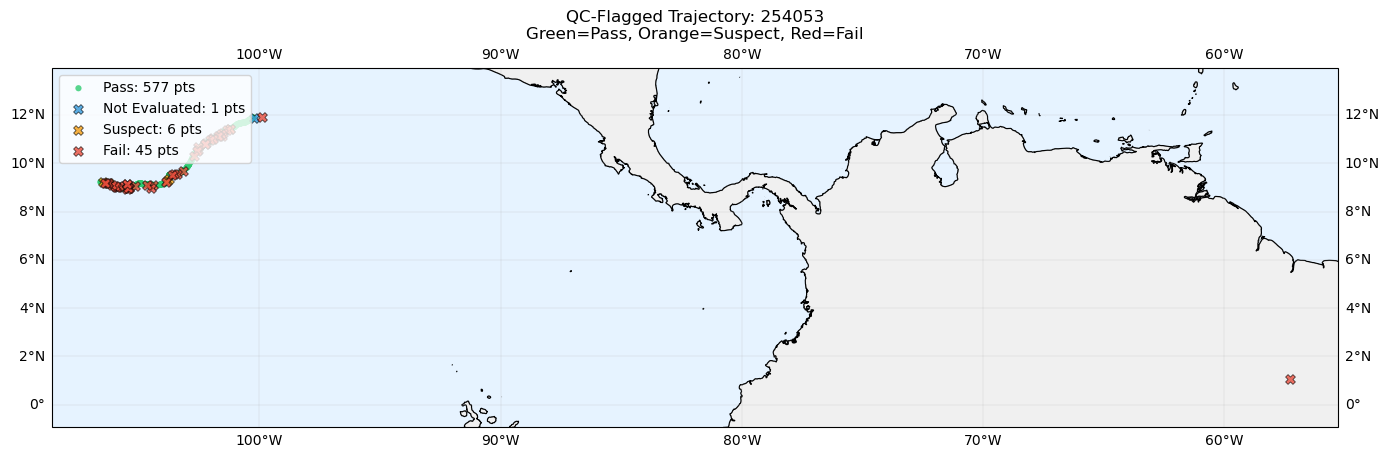

In [19]:
# Create a map showing QC-flagged trajectory
fig, ax = plt.subplots(1, 1, figsize=(14, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Use only valid coordinates for extent calculation
valid_coords = qc_df[(qc_df['lat'].between(-90, 90)) & (qc_df['lon'].between(-180, 180))]
lon_min = valid_coords['lon'].min() - 2
lon_max = valid_coords['lon'].max() + 2
lat_min = valid_coords['lat'].min() - 2
lat_max = valid_coords['lat'].max() + 2

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='gray')
ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Define colors for each flag value
flag_colors = {1: '#2ecc71', 2: '#3498db', 3: '#f39c12', 4: '#e74c3c', 9: '#95a5a6'}
flag_labels = {1: 'Pass', 2: 'Not Evaluated', 3: 'Suspect', 4: 'Fail', 9: 'Missing'}

# Plot trajectory line for good points only
good_mask = qc_df['qc_aggregate'] == 1
ax.plot(qc_df.loc[good_mask, 'lon'], qc_df.loc[good_mask, 'lat'],
        'g-', linewidth=0.5, alpha=0.3, transform=ccrs.PlateCarree())

# Plot points colored by QC flag
for flag_val in sorted(qc_df['qc_aggregate'].unique()):
    mask = qc_df['qc_aggregate'] == flag_val
    subset = qc_df[mask]
    valid_subset = subset[(subset['lat'].between(-90, 90)) & (subset['lon'].between(-180, 180))]
    
    if len(valid_subset) > 0:
        ax.scatter(valid_subset['lon'], valid_subset['lat'],
                   c=flag_colors.get(flag_val, 'gray'),
                   s=50 if flag_val > 1 else 20,
                   marker='o' if flag_val == 1 else 'X',
                   transform=ccrs.PlateCarree(),
                   label=f"{flag_labels.get(flag_val, f'Unknown')}: {len(subset)} pts",
                   zorder=5 if flag_val > 1 else 4,
                   edgecolors='black' if flag_val > 1 else 'none',
                   linewidths=0.5,
                   alpha=0.8)

# Get deployment ID
deploy_id = qc_df['DeployID'].iloc[0] if 'DeployID' in qc_df.columns else 'Deployment'

ax.legend(loc='upper left', fontsize=10)
ax.set_title(f"QC-Flagged Trajectory: {deploy_id}\nGreen=Pass, Orange=Suspect, Red=Fail", fontsize=12)
plt.tight_layout()
plt.show()

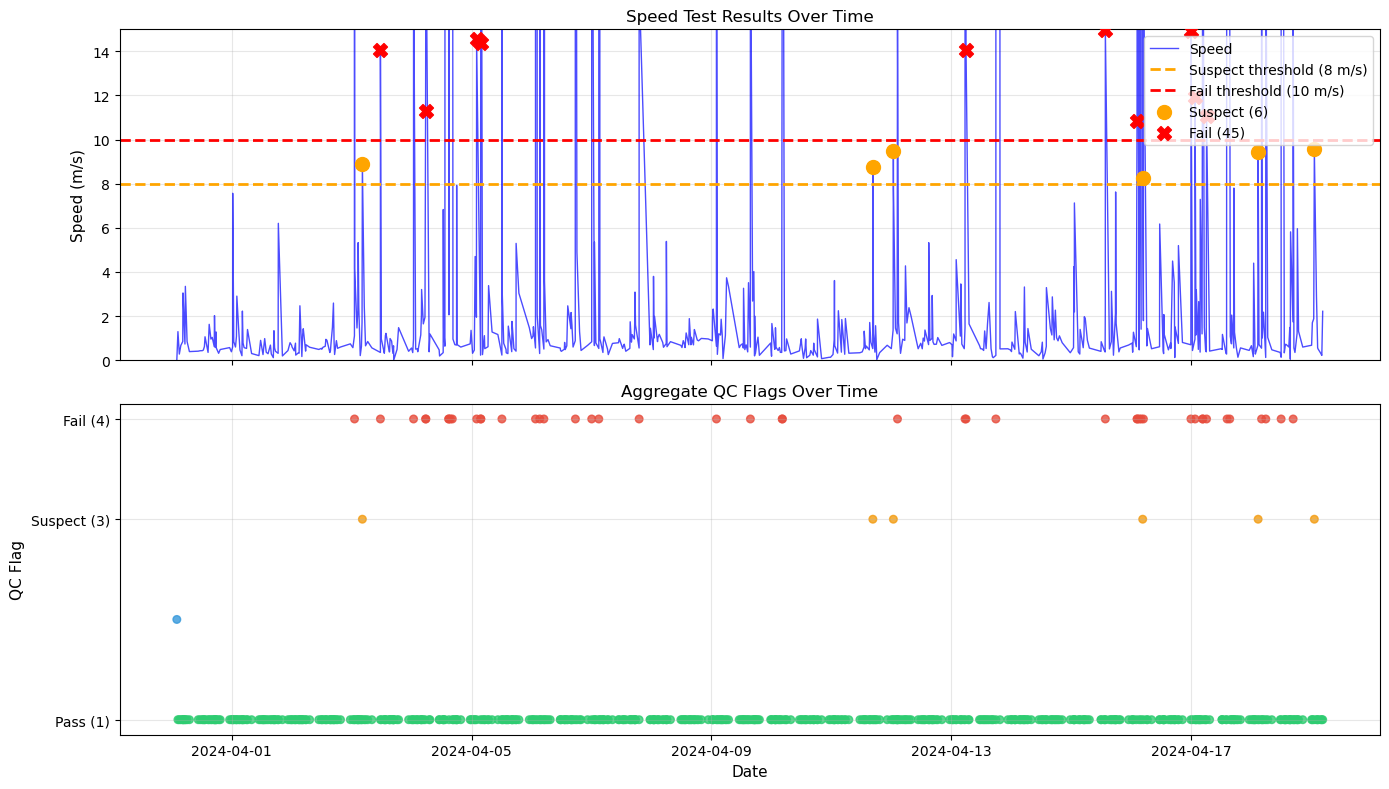

In [20]:
# Create speed time series plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: Speed over time with thresholds
ax1 = axes[0]
ax1.plot(qc_df['time'], qc_df['calculated_speed'], 'b-', alpha=0.7, linewidth=1, label='Speed')
ax1.axhline(y=8.0, color='orange', linestyle='--', linewidth=2, label='Suspect threshold (8 m/s)')
ax1.axhline(y=10.0, color='red', linestyle='--', linewidth=2, label='Fail threshold (10 m/s)')

# Highlight flagged points
suspect_mask = qc_df['speed_test'] == 3
fail_mask = qc_df['speed_test'] == 4
if suspect_mask.any():
    ax1.scatter(qc_df.loc[suspect_mask, 'time'], qc_df.loc[suspect_mask, 'calculated_speed'],
                c='orange', s=100, marker='o', zorder=5, label=f'Suspect ({suspect_mask.sum()})')
if fail_mask.any():
    ax1.scatter(qc_df.loc[fail_mask, 'time'], qc_df.loc[fail_mask, 'calculated_speed'],
                c='red', s=100, marker='X', zorder=5, label=f'Fail ({fail_mask.sum()})')

ax1.set_ylabel('Speed (m/s)', fontsize=11)
ax1.set_title('Speed Test Results Over Time', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Set reasonable y-limit
max_speed = qc_df['calculated_speed'].quantile(0.99) if len(qc_df) > 10 else qc_df['calculated_speed'].max()
ax1.set_ylim(0, min(max_speed * 1.5, 15))

# Plot 2: QC flag values over time  
ax2 = axes[1]
flag_colors_map = {1: '#2ecc71', 3: '#f39c12', 4: '#e74c3c', 9: '#95a5a6'}
colors = [flag_colors_map.get(f, '#3498db') for f in qc_df['qc_aggregate']]
ax2.scatter(qc_df['time'], qc_df['qc_aggregate'], c=colors, s=30, alpha=0.8)
ax2.set_ylabel('QC Flag', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_yticks([1, 3, 4])
ax2.set_yticklabels(['Pass (1)', 'Suspect (3)', 'Fail (4)'])
ax2.set_title('Aggregate QC Flags Over Time', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## QC Profile Data

Many Wildlife Computers tags also collect **time-series data** including temperature and depth measurements. For this example, we'll use the `SST.csv` file which contains temperature measurements.

For profile/time-series data, the ATN DAC applies QARTOD tests:

| Test | Variable | Fail Range | Description |
|------|----------|------------|-------------|
| `gross_range_test` | Temperature | [-2.5, 40] °C | Physical bounds for seawater temperature |
| `gross_range_test` | Salinity | [0, 41] PSU | Physical bounds for seawater salinity |
| `valid_range_test` | Time | Deployment period | Flags data outside deployment dates |

Let's load the SST data from our deployment.

In [23]:
# Load SST (Sea Surface Temperature) data for profile QC
# SST.csv contains temperature measurements at or near the surface

# List all CSV files in the deployment
all_csv_files = [f for f in zf.namelist() if f.endswith('.csv')]
print("CSV files in deployment ZIP:")
for f in sorted(all_csv_files):
    print(f"  - {f}")

# Find SST file using our helper function
sst_file = [f for f in all_csv_files if 'sst' in f.lower() and f.endswith('.csv')]

profile_df = None
if sst_file:
    print(f"\n✓ Found SST data: {sst_file}")
    with zf.open(sst_file[0]) as f:
        profile_df = pd.read_csv(f)
    print(f"  Loaded {len(profile_df)} records")
    print(f"\nColumns: {list(profile_df.columns)}")
    display(profile_df.head())
else:
    print("\n⚠ No SST.csv found in this deployment")
    print("  (This deployment may be trajectory-only)")

CSV files in deployment ZIP:
  - 254053O2024/254053-10-GPE3.csv
  - 254053O2024/254053-All.csv
  - 254053O2024/254053-Argos.csv
  - 254053O2024/254053-Corrupt.csv
  - 254053O2024/254053-Histos.csv
  - 254053O2024/254053-Labels.csv
  - 254053O2024/254053-LightLoc.csv
  - 254053O2024/254053-Locations.csv
  - 254053O2024/254053-MinMaxDepth.csv
  - 254053O2024/254053-MixLayer.csv
  - 254053O2024/254053-PDTs.csv
  - 254053O2024/254053-RTC.csv
  - 254053O2024/254053-RawArgos.csv
  - 254053O2024/254053-SST.csv
  - 254053O2024/254053-Series.csv
  - 254053O2024/254053-SeriesRange.csv
  - 254053O2024/254053-Status.csv
  - 254053O2024/254053-Summary.csv

✓ Found SST data: ['254053O2024/254053-SST.csv']
  Loaded 1019 records

Columns: ['DeployID', 'Ptt', 'DepthSensor', 'Instr', 'Date', 'LocationQuality', 'Latitude', 'Longitude', 'Depth', 'Temperature', 'Source']


,DeployID,Ptt,DepthSensor,Instr,Date,LocationQuality,Latitude,Longitude,Depth,Temperature,Source
0,254053,254053,0.5,MiniPAT,20:00:00 16-Jan-2024,NaN,NaN,NaN,0.4,29.3,TimeSeries
1,254053,254053,0.5,MiniPAT,00:00:00 17-Jan-2024,NaN,NaN,NaN,0.4,28.3,TimeSeries
2,254053,254053,0.5,MiniPAT,01:00:00 17-Jan-2024,NaN,NaN,NaN,0.4,28.3,TimeSeries
3,254053,254053,0.5,MiniPAT,02:00:00 17-Jan-2024,NaN,NaN,NaN,0.4,28.3,TimeSeries
4,254053,254053,0.5,MiniPAT,04:00:00 17-Jan-2024,NaN,NaN,NaN,0.4,28.0,TimeSeries


In [24]:
# If we have profile/series data, apply QC tests
# This mirrors the QC applied in packrat/platforms/utils.py default_qc_config()

if profile_df is not None and len(profile_df) > 0:
    # Find temperature column (various naming conventions)
    temp_col = None
    depth_col = None
    time_col = None
    
    for col in profile_df.columns:
        col_lower = col.lower()
        if 'temp' in col_lower and temp_col is None:
            temp_col = col
        if 'depth' in col_lower and depth_col is None:
            depth_col = col
        if 'date' in col_lower or 'time' in col_lower:
            time_col = col
    
    print(f"Identified columns:")
    print(f"  Temperature: {temp_col}")
    print(f"  Depth: {depth_col}")
    print(f"  Time: {time_col}")
    
    # Prepare profile dataframe for QC
    profile_qc_df = profile_df.copy()
    
    if time_col:
        profile_qc_df['time'] = pd.to_datetime(profile_qc_df[time_col])
        profile_qc_df = profile_qc_df.sort_values('time').reset_index(drop=True)
    
    # Standardize column names for QC
    if temp_col:
        profile_qc_df['temperature'] = pd.to_numeric(profile_qc_df[temp_col], errors='coerce')
    if depth_col:
        profile_qc_df['depth'] = pd.to_numeric(profile_qc_df[depth_col], errors='coerce')
    
    print(f"\nProfile data prepared for QC: {len(profile_qc_df)} records")
    
    if temp_col:
        print(f"\nTemperature statistics:")
        print(f"  Min: {profile_qc_df['temperature'].min():.2f} °C")
        print(f"  Max: {profile_qc_df['temperature'].max():.2f} °C")
        print(f"  Mean: {profile_qc_df['temperature'].mean():.2f} °C")
else:
    print("No profile data available for QC demonstration")

Identified columns:
  Temperature: Temperature
  Depth: DepthSensor
  Time: Date

Profile data prepared for QC: 1019 records

Temperature statistics:
  Min: 17.40 °C
  Max: 32.60 °C
  Mean: 28.35 °C


### Apply Gross Range Test to Temperature

The **gross_range_test** checks if values fall within physically plausible bounds. For temperature, the ATN DAC uses the Argo QC Manual thresholds:
- **Fail bounds**: [-2.5, 40] °C (values outside this range are flagged as FAIL)

This test catches sensor malfunctions that report impossible temperatures.

In [25]:
# Apply gross_range_test to temperature data
# This matches the QC in packrat/platforms/utils.py

from ioos_qc.qartod import gross_range_test

if profile_df is not None and 'temperature' in profile_qc_df.columns:
    # ATN DAC thresholds from Argo QC Manual
    # See: packrat/platforms/utils.py default_qc_config()
    TEMP_FAIL_MIN = -2.5
    TEMP_FAIL_MAX = 40.0
    
    temp_flags = gross_range_test(
        inp=profile_qc_df['temperature'].values,
        fail_span=[TEMP_FAIL_MIN, TEMP_FAIL_MAX]
    )
    
    profile_qc_df['temperature_qartod_gross_range_test'] = temp_flags
    
    print("Temperature Gross Range Test Results")
    print("="*50)
    print(f"Fail bounds: [{TEMP_FAIL_MIN}, {TEMP_FAIL_MAX}] °C")
    print(f"\nFlag distribution:")
    flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
    for flag, count in pd.Series(temp_flags).value_counts().sort_index().items():
        pct = 100 * count / len(temp_flags)
        print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")
    
    # Show any failed values
    failed_temp = profile_qc_df[profile_qc_df['temperature_qartod_gross_range_test'] == 4]
    if len(failed_temp) > 0:
        print(f"\n⚠ {len(failed_temp)} temperature values failed gross_range_test:")
        print(failed_temp[['time', 'temperature', 'temperature_qartod_gross_range_test']].head(10))
    else:
        print(f"\n✓ All temperature values passed the gross_range_test")
else:
    print("No temperature data available for QC")

Temperature Gross Range Test Results
Fail bounds: [-2.5, 40.0] °C

Flag distribution:
  PASS (1):  1019 (100.0%)

✓ All temperature values passed the gross_range_test


### Apply Valid Range Test to Time

The **valid_range_test** checks that observations fall within the deployment period. This catches data with timestamp errors or data logged before/after the tag was deployed.

In [26]:
# Apply valid_range_test to time
# This uses ioos_qc.axds.valid_range_test as used in packrat

from ioos_qc.axds import valid_range_test

if profile_df is not None and 'time' in profile_qc_df.columns:
    # Define deployment period from the data itself
    # In production, these come from the PI-specified dates in ADR
    deploy_start = profile_qc_df['time'].min()
    deploy_end = profile_qc_df['time'].max()
    
    print(f"Deployment period: {deploy_start} to {deploy_end}")
    
    # Convert to ISO format strings as expected by valid_range_test
    time_flags = valid_range_test(
        inp=profile_qc_df['time'].values,
        valid_span=[
            deploy_start.isoformat(),
            deploy_end.isoformat()
        ]
    )
    
    profile_qc_df['time_axds_valid_range_test'] = time_flags
    
    print("\nTime Valid Range Test Results")
    print("="*50)
    flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
    for flag, count in pd.Series(time_flags).value_counts().sort_index().items():
        pct = 100 * count / len(time_flags)
        print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")
else:
    print("No time data available for valid_range_test")

Deployment period: 2024-01-16 20:00:00 to 2024-04-19 00:00:00

Time Valid Range Test Results
  PASS (1):  1018 (99.9%)
  FAIL (4):     1 (0.1%)


### Visualize Profile QC Results

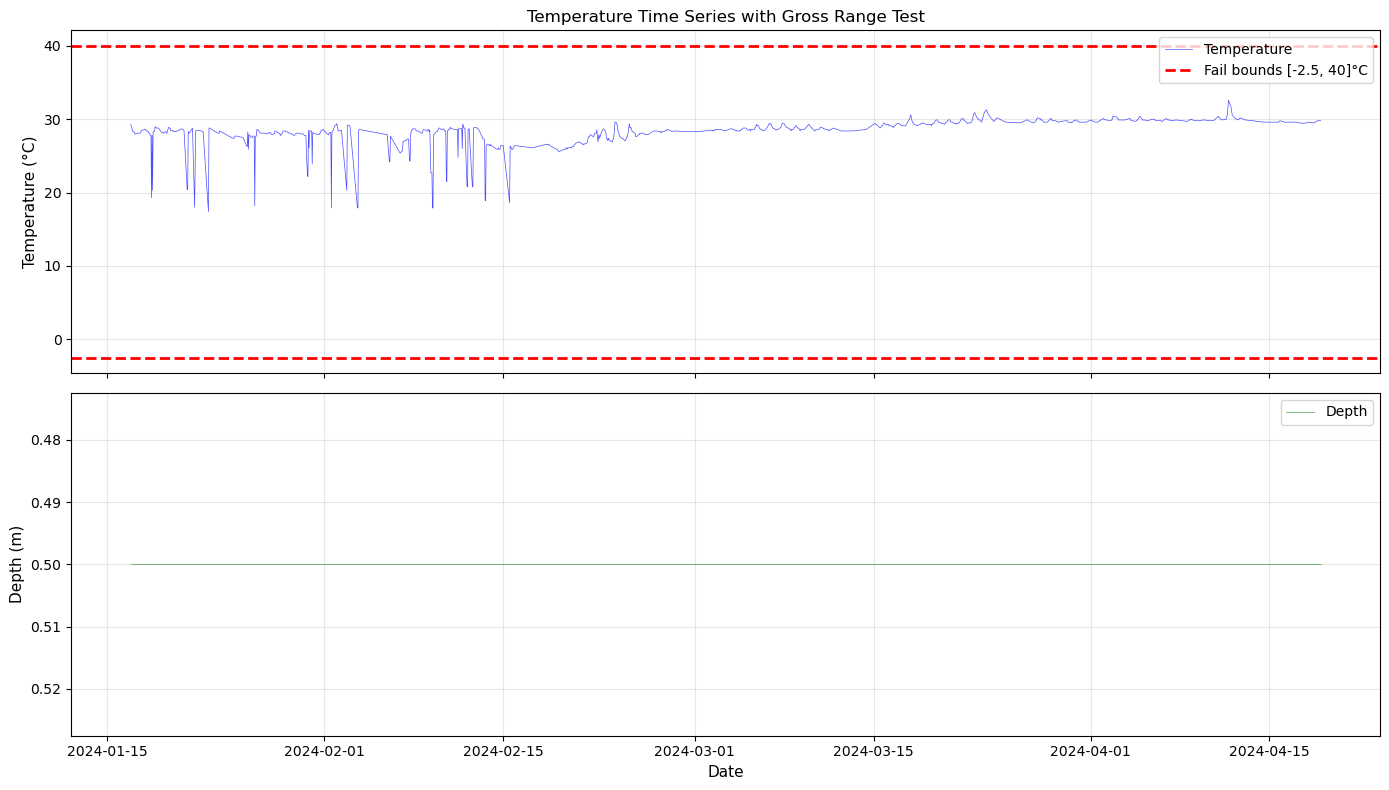

In [27]:
# Visualize temperature time series with QC flags
if profile_df is not None and 'temperature' in profile_qc_df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Plot 1: Temperature time series with QC thresholds
    ax1 = axes[0]
    ax1.plot(profile_qc_df['time'], profile_qc_df['temperature'], 
             'b-', alpha=0.7, linewidth=0.5, label='Temperature')
    
    # Show QC thresholds
    ax1.axhline(y=-2.5, color='red', linestyle='--', linewidth=2, 
                label='Fail bounds [-2.5, 40]°C')
    ax1.axhline(y=40, color='red', linestyle='--', linewidth=2)
    
    # Highlight any failed points
    if 'temperature_qartod_gross_range_test' in profile_qc_df.columns:
        fail_mask = profile_qc_df['temperature_qartod_gross_range_test'] == 4
        if fail_mask.any():
            ax1.scatter(profile_qc_df.loc[fail_mask, 'time'], 
                       profile_qc_df.loc[fail_mask, 'temperature'],
                       c='red', s=50, marker='X', zorder=5, 
                       label=f'Failed ({fail_mask.sum()})')
    
    ax1.set_ylabel('Temperature (°C)', fontsize=11)
    ax1.set_title('Temperature Time Series with Gross Range Test', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Depth if available
    ax2 = axes[1]
    if 'depth' in profile_qc_df.columns:
        ax2.plot(profile_qc_df['time'], profile_qc_df['depth'], 
                 'g-', alpha=0.7, linewidth=0.5, label='Depth')
        ax2.set_ylabel('Depth (m)', fontsize=11)
        ax2.invert_yaxis()  # Depth increases downward
        ax2.legend(loc='upper right')
    else:
        ax2.text(0.5, 0.5, 'No depth data available', ha='center', va='center',
                transform=ax2.transAxes, fontsize=12, color='gray')
    
    ax2.set_xlabel('Date', fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No profile data available for visualization")

## Using PandasStream for Batch QC

In the ATN DAC production pipeline, QC tests are run using `ioos_qc`'s `PandasStream` and `PandasStore` classes. This approach:
1. Applies all configured tests in a single pass
2. Automatically computes aggregate (rollup) flags
3. Produces standardized output column names

Here's how ATN DAC runs QC:

In [ ]:
# Production QC approach for trajectory data using PandasStream

def apply_trajectory_qc(df, qc_config_yaml):
    """
    Apply batch QC approach to trajectory data
    """
    config = Config(qc_config_yaml)
    stream = PandasStream(df)
    results = stream.run(config)
    
    store = PandasStore(
        results,
        axes={
            't': 'time',
            'x': 'lon',
            'y': 'lat'
        }
    )
    
    store.compute_aggregate(name='qartod_rollup_qc')
    results_df = store.save(write_data=False, write_axes=False)
    
    return pd.concat([df, results_df], axis=1)

# Build QC configuration YAML for trajectory (matching packrat defaults)
trajectory_qc_yaml = """
lon:
    qartod:
        location_test:
            bbox: [-180, -90, 180, 90]
            lat: lat
lat:
    argo:
        speed_test:
            tinp: timestamp
            lon: lon
            suspect_threshold: 8.0
            fail_threshold: 10.0
"""

print("Trajectory QC Configuration (YAML format):")
print(trajectory_qc_yaml)

# Run QC 
trajectory_qc_results = apply_trajectory_qc(qc_df, trajectory_qc_yaml)

print("\n" + "="*50)
print("Trajectory QC Results")
print("="*50)

# Show QC columns added
qc_cols = [c for c in trajectory_qc_results.columns if 'test' in c.lower() or 'rollup' in c.lower()]
print(f"\nQC columns added: {qc_cols}")

# Show rollup summary
if 'qartod_rollup_qc' in trajectory_qc_results.columns:
    print(f"\nAggregate QC (qartod_rollup_qc) distribution:")
    flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
    for flag, count in trajectory_qc_results['qartod_rollup_qc'].value_counts().sort_index().items():
        pct = 100 * count / len(trajectory_qc_results)
        print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")

In [ ]:
# Production QC approach using PandasStream

def apply_profile_qc(df, qc_config_yaml):
    """
    Apply batch QC approach to profile data
    """
    # Parse the YAML config
    config = Config(qc_config_yaml)
    
    # Setup the stream
    stream = PandasStream(df)
    
    # Run the tests
    results = stream.run(config)
    
    # Store the results
    store = PandasStore(
        results,
        axes={
            't': 'time',
            'z': 'z' if 'z' in df.columns else None,
            'y': 'lat' if 'lat' in df.columns else None,
            'x': 'lon' if 'lon' in df.columns else None
        }
    )
    
    # Compute aggregate rollup flag
    store.compute_aggregate(name='qartod_rollup_qc')
    
    # Get results as DataFrame
    results_df = store.save(write_data=False, write_axes=False)
    
    # Append QC columns to original data
    return pd.concat([df, results_df], axis=1)

# Example: Define QC config for profile data (matching packrat defaults)
if profile_df is not None and 'temperature' in profile_qc_df.columns:
    
    # Get deployment time bounds
    deploy_start = profile_qc_df['time'].min().isoformat()
    deploy_end = profile_qc_df['time'].max().isoformat()
    
    # Build QC configuration YAML (same format as packrat)
    profile_qc_yaml = f"""
    time:
        axds:
            valid_range_test:
                valid_span:
                    - {deploy_start}
                    - {deploy_end}
    temperature:
        qartod:
            gross_range_test:
                fail_span: [-2.5, 40]
    """
    
    print("QC Configuration (YAML format):")
    print(profile_qc_yaml)
    
    # Run QC
    profile_qc_results = apply_profile_qc(profile_qc_df, profile_qc_yaml)
    
    print("\n" + "="*50)
    print("QC Results")
    print("="*50)
    
    # Show QC columns added
    qc_cols = [c for c in profile_qc_results.columns if 'qc' in c.lower() or 'test' in c.lower()]
    print(f"\nQC columns added: {qc_cols}")
    
    # Show rollup summary
    if 'qartod_rollup_qc' in profile_qc_results.columns:
        print(f"\nAggregate QC (qartod_rollup_qc) distribution:")
        for flag, count in profile_qc_results['qartod_rollup_qc'].value_counts().sort_index().items():
            pct = 100 * count / len(profile_qc_results)
            flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
            print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")
else:
    print("No profile data available for demonstration")

## 9. Summary

This notebook demonstrated the QARTOD QC tests applied by the ATN Data Assembly Center to animal telemetry data. The key tests are:

### Trajectory QC
| Test | Module | Thresholds | Purpose |
|------|--------|------------|---------|
| `location_test` | `ioos_qc.qartod` | bbox: [-180, -90, 180, 90] | Valid geographic bounds |
| `speed_test` | `ioos_qc.argo` | suspect: 8 m/s, fail: 10 m/s | Realistic movement speeds |

### Profile/Time-Series QC  
| Test | Module | Thresholds | Purpose |
|------|--------|------------|---------|
| `gross_range_test` | `ioos_qc.qartod` | temp: [-2.5, 40]°C | Physical sensor bounds |
| `gross_range_test` | `ioos_qc.qartod` | salinity: [0, 41] PSU | Physical sensor bounds |
| `valid_range_test` | `ioos_qc.axds` | deployment dates | Deployment period bounds |

### Production Implementation

The ATN DAC pipeline (packrat) uses:
- `ioos_qc.streams.PandasStream` to run tests
- `ioos_qc.stores.PandasStore` to store results
- `qartod_rollup_qc` aggregate flag combining all test results

QC flags are added as columns to the data (e.g., `temperature_qartod_gross_range_test`) and included in the final NetCDF files distributed via the ATN Data Portal.

---

### References

- [ATN Data Portal](https://portal.atn.ioos.us/)
- [IOOS QARTOD Manual](https://ioos.noaa.gov/project/qartod/)
- [ioos_qc Documentation](https://ioos.github.io/ioos_qc/)
- [Argo Quality Control Manual](https://archimer.ifremer.fr/doc/00228/33951/)
- [Wildlife Computers Data Portal](https://my.wildlifecomputers.com/)
- [ATN DAC Specification](https://github.com/ioos/ioos-atn-data/wiki/ATN-DAC-Specification)